<a href="https://colab.research.google.com/github/yiferu2123/amharic_hateSpeachRemoval_bot/blob/main/editedHateSpeachRemoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🇪🇹 Amharic Hate Speech Dataset Collection
This notebook collects Amharic hate speech datasets from:
- **Zenodo** (AMHSDataTrain.txt & AMHSDataTest.txt)
- **HuggingFace Hub** (uhhlt/amharichatespeechranlp)

In [ ]:
# Install required libraries
!pip install datasets pandas matplotlib

In [ ]:
# Download Amharic Hate Speech datasets from Zenodo
!wget https://zenodo.org/records/5036437/files/AMHSDataTrain.txt
!wget https://zenodo.org/records/5036437/files/AMHSDataTest.txt

## 🐼 Cell 3 — Load Zenodo Data into Pandas


In [ ]:
# See exact raw content of the file
with open('AMHSDataTrain.txt', 'rb') as f:
    raw_bytes = f.read(300)

print("RAW BYTES (first 300):")
print(repr(raw_bytes))

print("\n\nFIRST 5 LINES:")
with open('AMHSDataTrain.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(f"[Line {i}]: {repr(line)}")


In [ ]:
import pandas as pd

def parse_amhs_file(filepath):
    """
    Handles the format where each line looks like:
      "Amharic text here,ጥላቻ"
    i.e. the entire row is wrapped in one quoted block.
    """
    rows = []
    # Try multiple encodings
    for enc in ['utf-8-sig', 'utf-8', 'latin-1']:
        try:
            with open(filepath, 'r', encoding=enc) as f:
                raw_lines = f.readlines()
            print(f"✅ Opened with encoding: {enc}")
            break
        except Exception as e:
            print(f"❌ Failed with {enc}: {e}")
            raw_lines = []

    for i, line in enumerate(raw_lines):
        line = line.strip()
        if not line:
            continue

        # ── Strip outer quotes ──────────────────────────────
        # Handles the "entire,row,in,quotes" format
        while line.startswith('"') and line.endswith('"') and len(line) > 1:
            line = line[1:-1].strip()

        # ── Skip header row ─────────────────────────────────
        if line.lower().replace(' ', '') in (
            'content,label', 'text,label', 'ጽሑፍ,መለያ', 'አጻጻፍ,መለያ'
        ):
            print(f"⏭️  Skipped header at line {i}: {line}")
            continue

        # ── Split on LAST comma (label is always last) ──────
        parts = line.rsplit(',', 1)
        if len(parts) == 2:
            text  = parts[0].strip().strip('"').strip()
            label = parts[1].strip().strip('"').strip()
            if text:
                rows.append({'text': text, 'label': label if label else None})
        else:
            text = line.strip('"').strip()
            if text:
                rows.append({'text': text, 'label': None})

    df = pd.DataFrame(rows)
    return df

# Load files
df_train_zenodo = parse_amhs_file('AMHSDataTrain.txt')
df_test_zenodo  = parse_amhs_file('AMHSDataTest.txt')

print("\n=== Zenodo TRAIN ===")
print(f"Shape: {df_train_zenodo.shape}")
print(df_train_zenodo['label'].value_counts())
print(df_train_zenodo.head(5))

print("\n=== Zenodo TEST ===")
print(f"Shape: {df_test_zenodo.shape}")
print(df_test_zenodo['label'].value_counts())
print(df_test_zenodo.head(5))


## 🤗 Cell 4 — Load HuggingFace Dataset

In [ ]:
from datasets import load_dataset
dataset = load_dataset("uhhlt/amharichatespeechranlp")
print(dataset)


## 🐼 Cell 5 — Convert HuggingFace Dataset to Pandas

In [ ]:
df_train_hf = dataset['train'].to_pandas()[['text', 'label']]
df_test_hf  = dataset['test'].to_pandas()[['text', 'label']]

print("HuggingFace TRAIN label counts:")
print(df_train_hf['label'].value_counts())
print("\nHuggingFace TEST label counts:")
print(df_test_hf['label'].value_counts())


## 📊 Cell 6 — Combined Overview & Label Distribution

In [ ]:
import pandas as pd

# ── Label map: everything → 2 labels ──────────────────────────
LABEL_MAP = {
    # English (HuggingFace)
    'hate'      : 'ጥላቻ',
    'offensive' : 'ጥላቻ',
    'normal'    : 'መልካም',
    # Amharic (Zenodo) — may include these
    'ጥላቻ'      : 'ጥላቻ',
    'ጸያፍ'      : 'ጥላቻ',
    'ተቃዋሚ'    : 'ጥላቻ',
    'ነጻ'        : 'መልካም',
    'ተራ'       : 'መልካም',
    'መልካም'     : 'መልካም',
}

def normalize(df):
    df = df.copy()
    df['label'] = df['label'].astype(str).str.strip().map(LABEL_MAP)
    df = df.dropna(subset=['label'])
    df = df[df['text'].astype(str).str.strip() != '']
    return df.reset_index(drop=True)

# Normalize all four splits
z_train = normalize(df_train_zenodo)
z_test  = normalize(df_test_zenodo)
h_train = normalize(df_train_hf)
h_test  = normalize(df_test_hf)

# ── Merge ───────────────────────────────────────────────────────
df_train_all = (pd.concat([z_train, h_train], ignore_index=True)
                  .drop_duplicates(subset='text')
                  .reset_index(drop=True))

df_test_all  = (pd.concat([z_test, h_test], ignore_index=True)
                  .drop_duplicates(subset='text')
                  .reset_index(drop=True))

print("=" * 50)
print("📊 MERGED TRAIN DATASET")
print("=" * 50)
print(f"Rows  : {len(df_train_all)}")
print(f"Labels:\n{df_train_all['label'].value_counts()}")
print(df_train_all.head(10))

print("\n" + "=" * 50)
print("📊 MERGED TEST DATASET")
print("=" * 50)
print(f"Rows  : {len(df_test_all)}")
print(f"Labels:\n{df_test_all['label'].value_counts()}")
print(df_test_all.head(10))


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#e74c3c', '#2ecc71']

for ax, df, title in zip(
    axes,
    [df_train_all, df_test_all],
    ['Merged TRAIN Label Distribution', 'Merged TEST Label Distribution']
):
    counts = df['label'].value_counts()
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n✅ Final Train: {len(df_train_all)} rows | {df_train_all['label'].value_counts().to_dict()}")
print(f"✅ Final Test : {len(df_test_all)} rows | {df_test_all['label'].value_counts().to_dict()}")


Data Cleaning

In [ ]:
import pandas as pd

# ── Make sure both have only 'text' and 'label' columns ────────
zenodo_df = pd.concat([df_train_zenodo, df_test_zenodo], ignore_index=True)[['text', 'label']]
hf_df     = pd.concat([df_train_hf,    df_test_hf],     ignore_index=True)[['text', 'label']]

# ── Tag the source so you know where each row came from ────────
zenodo_df['source'] = 'Zenodo'
hf_df['source']     = 'HuggingFace'

# ── Stack rows vertically ──────────────────────────────────────
df_merged = pd.concat([zenodo_df, hf_df], ignore_index=True)

# ── Drop exact duplicates ──────────────────────────────────────
df_merged = df_merged.drop_duplicates(subset='text').reset_index(drop=True)

# ── Display ────────────────────────────────────────────────────
print(f"Zenodo rows      : {len(zenodo_df)}")
print(f"HuggingFace rows : {len(hf_df)}")
print(f"Total merged rows: {len(df_merged)}")
print(f"\nLabel counts:\n{df_merged['label'].value_counts()}")
print(f"\nSource counts:\n{df_merged['source'].value_counts()}")
print("\nFirst 10 rows:")
df_merged.head(10)


drop rows where label could not be mapped

In [ ]:
LABEL_MAP = {
    # English (HuggingFace)
    'hate'      : 'ጥላቻ',
    'offensive' : 'ጥላቻ',
    'normal'    : 'መልካም',
    # Amharic (Zenodo)
    'ጥላቻ'      : 'ጥላቻ',
    'ጸያፍ'      : 'ጥላቻ',
    'ተቃዋሚ'    : 'ጥላቻ',
    'ነጻ'        : 'መልካም',
    'ተራ'       : 'መልካም',
    'መልካም'     : 'መልካም',
}

df_merged['label'] = df_merged['label'].astype(str).str.strip().map(LABEL_MAP)

# Drop rows where label couldn't be mapped
df_merged = df_merged.dropna(subset=['label']).reset_index(drop=True)

print(f"✅ Total rows after normalization: {len(df_merged)}")
print(f"\nFinal label counts:\n{df_merged['label'].value_counts()}")
print(f"\nSource breakdown:\n{df_merged['source'].value_counts()}")
print("\nSample rows:")
df_merged.head(10)


save to csv format

In [ ]:
# Save to CSV
df_merged.to_csv('amharic_hate_speech_merged.csv', index=False, encoding='utf-8-sig')
print("✅ Saved as amharic_hate_speech_merged.csv")


## 🛠️ Cell 8 — Data Preprocessing for Modeling
We map strings to integers and perform a train/test split.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_merged['label_encoded'] = encoder.fit_transform(df_merged['label'])

# 0 for መልካም (normal/good), 1 for ጥላቻ (hate)

X = df_merged['text'].astype(str).values
y = df_merged['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))


## 🧠 Cell 9 — Machine Learning Baseline (TF-IDF + Logistic Regression)
A fast and strong baseline model to establish a reference point.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

ml_model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
ml_model.fit(X_train_tfidf, y_train)

y_pred_ml = ml_model.predict(X_test_tfidf)

print("--- ML Baseline Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ml):.4f}")
print(classification_report(y_test, y_pred_ml, target_names=encoder.classes_))


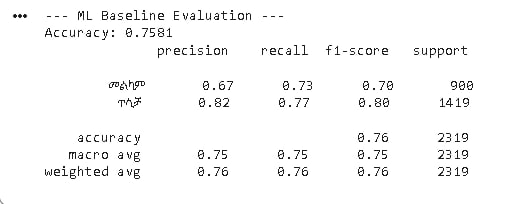

## 🚀 Cell 10 — Deep Learning: Transformers Setup
We will fine-tune a pre-trained XLM-RoBERTa model specific to Amharic text (`Davlan/xlm-roberta-base-finetuned-amharic`).
**Note**: Make sure you have changed your Colab Runtime to GPU (T4 or better) before running this!

In [ ]:
!pip install transformers datasets accelerate evaluate

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset, DatasetDict
import evaluate

model_name = "Davlan/xlm-roberta-base-finetuned-amharic"

# 1. Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Convert Data into HuggingFace Dataset Format
train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

hf_dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = hf_dataset.map(tokenize_fn, batched=True)

# 3. Load Model
dl_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


## 🏋️ Cell 11 — Train and Evaluate the Deep Learning Model
Train XLM-RoBERTa on the Amharic text. This might take 10-20 minutes depending on your Colab GPU.

In [ ]:
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./dl_amharic_hate_speech",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_steps=100,
)

trainer = Trainer(
    model=dl_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# START TRAINING
trainer.train()

# EVALUATE MODEL
trainer.evaluate()
